In [12]:
import numpy as np
import itertools
import matplotlib.pyplot as plt

In [13]:
# ---- Classical linear code definition ----
# Parity-check matrix H (shape (n-k) x n). Default: [3,1,3] repetition code.
H = np.array([[1, 1, 0],
              [0, 1, 1]]) % 2
n   = H.shape[1]          # number of physical bits   (3)
m   = H.shape[0]          # number of checks = n - k  (2)
k   = n - m               # logical bits              (1)
dim = 2 ** n              # state-space dimension      (8)

I2 = np.eye(2)
X  = np.array([[0., 1.], [1., 0.]])          # Pauli X = classical bit flip

def x_string(bits):
    """X^bits = tensor product of X on every position where bits[j]==1."""
    M = np.array([[1.0]])
    for b in bits:
        M = np.kron(M, X if b else I2)
    return M

def syndrome(e):
    """Syndrome H e (mod 2) of an n-bit error pattern e, returned as a tuple."""
    return tuple((H @ np.array(e)) % 2)

def build_decoder(H, n):
    """Minimum-weight lookup decoder: syndrome -> correction bitstring."""
    m = H.shape[0]
    table = {}
    for w in range(n + 1):                       # errors in order of increasing weight
        for combo in itertools.combinations(range(n), w):
            e = np.zeros(n, dtype=int)
            for i in combo:
                e[i] = 1
            s = tuple((H @ e) % 2)
            if s not in table:                   # keep first (lowest-weight) representative
                table[s] = e
        if len(table) == 2 ** m:
            break
    return table

decoder = build_decoder(H, n)

def R_op(s):
    """Recovery operator R_s = X^{corr(s)} for syndrome s."""
    return x_string(decoder[tuple(np.array(s) % 2)])

{s: list(c) for s, c in decoder.items()}     # show the decoding table

{(np.int64(0), np.int64(0)): [np.int64(0), np.int64(0), np.int64(0)],
 (np.int64(1), np.int64(0)): [np.int64(1), np.int64(0), np.int64(0)],
 (np.int64(1), np.int64(1)): [np.int64(0), np.int64(1), np.int64(0)],
 (np.int64(0), np.int64(1)): [np.int64(0), np.int64(0), np.int64(1)]}

In [14]:
# ---- Error model ----
# Independent bit-flip with parameter q, applied both to the n-bit error pattern e~
# and (directly) to the (n-k)-bit syndrome label e_i.
def p_error(e, q):
    """p(e~) = prod_j q^{e_j} (1-q)^{1-e_j} for an n-bit error pattern e."""
    w = int(np.sum(e))
    return q ** w * (1 - q) ** (n - w)

def syndrome_dist(q):
    """Syndrome-label distribution p(e_i): each of the (n-k) syndrome bits is an
    independent bit-flip(q).  Same iid form as p_error, applied to the length-(n-k)
    syndrome bitstring (NOT induced from the error distribution)."""
    return {e: q ** int(sum(e)) * (1 - q) ** (m - int(sum(e))) for e in S}

S = list(itertools.product([0, 1], repeat=m))   # all 2^(n-k) syndrome labels

In [15]:
# ---- Channel construction via superoperators ----
# Column-major vectorization: the map  rho -> K rho K^dagger  becomes  (K* (x) K) vec(rho).
def to_super(K):   return np.kron(K.conj(), K)
def vec(rho):      return rho.reshape(-1, order='F')
def unvec(v):      return v.reshape(dim, dim, order='F')
ISUP = np.eye(dim * dim, dtype=complex)          # identity superoperator (channel at t=0)

def build_SQ(q):
    """SQ[ei][eim1] = superoperator of  Q(e_i, e_{i-1})[rho]
       = sum_{e~} p(e~) R_s X^{e~} rho X^{e~} R_s,  with s = (H e~ + e_i + e_{i-1}) mod 2."""
    SQ = {ei: {} for ei in S}
    for ei in S:
        for eim1 in S:
            acc = np.zeros((dim * dim, dim * dim), dtype=complex)
            for et in itertools.product([0, 1], repeat=n):
                s = tuple((np.array(syndrome(et)) + np.array(ei) + np.array(eim1)) % 2)
                U = R_op(s) @ x_string(et)       # recovery composed with the error
                acc += p_error(et, q) * to_super(U)
            SQ[ei][eim1] = acc
    return SQ

def build_all_channels(T, q):
    """Cache the superoperator of channel(t) for t = 0..T.

    channel(t) = sum_{e1..et} p(e1)..p(et) R(et) Q(et,e_{t-1})..Q(e2,e1) R(e1).
    Built by a transfer-matrix recursion over the syndrome path e1 -> ... -> et."""
    psyn = syndrome_dist(q)
    SR   = {e: to_super(R_op(e)) for e in S}     # recovery superoperators
    SQ   = build_SQ(q)
    chans = {0: ISUP.copy()}                      # channel(0) = identity
    C = {e: psyn[e] * SR[e] for e in S}           # state after the initial R(e1), weighted by p(e1)
    chans[1] = sum(C[e] for e in S)               # t=1: a single recovery, no trailing R
    for t in range(2, T + 1):
        C = {ei: psyn[ei] * sum(SQ[ei][eim1] @ C[eim1] for eim1 in S) for ei in S}
        chans[t] = sum(SR[e] @ C[e] for e in S)   # apply the trailing R(e_t) and sum over e_t
    return chans

def make_channel(chans):
    """Wrap the cached superoperators as a callable channel(t, rho)."""
    return lambda t, rho: unvec(chans[t] @ vec(rho))

In [16]:
# ---- Non-Markovianity (BLP) measure ----
# trace_norm(diag(p1-p2)) = ||p1-p2||_1 = 2 * total-variation distance for the classical case.
def trace_norm(A):
    return np.sum(np.abs(np.linalg.eigvalsh(A)))

def non_markovian_measure(channel, T, rho1, rho2):
    rho = rho1 - rho2
    measure = 0
    for t in range(1, T):
        measure += max(0, 0.5 * (trace_norm(channel(t, rho)) - trace_norm(channel(t - 1, rho))))

    return measure

In [17]:
# ---- Sweep rho1, rho2 over all physical basis states; find the maximum ----
def basis_state(i):
    """Pure computational-basis state |i><i| as a diagonal density matrix."""
    rho = np.zeros((dim, dim), dtype=complex)
    rho[i, i] = 1.0
    return rho

def max_measure(T, q):
    """Maximum non-Markovian measure over all pairs of basis states, plus the optimal pair."""
    channel = make_channel(build_all_channels(T, q))
    best_val, best_pair = -1.0, None
    for i in range(dim):
        for j in range(i + 1, dim):
            v = non_markovian_measure(channel, T, basis_state(i), basis_state(j))
            if v > best_val:
                best_val, best_pair = v, (i, j)
    return best_val, best_pair

T = 12
q = 0.1
val, (i, j) = max_measure(T, q)
print(f"code: n={n}, k={k}   T={T}   q={q}")
print(f"max non-Markovian measure = {val:.6f}")
print(f"optimal state pair: |{i:0{n}b}>  vs  |{j:0{n}b}>")

code: n=3, k=1   T=12   q=0.1
max non-Markovian measure = 0.180000
optimal state pair: |100>  vs  |101>


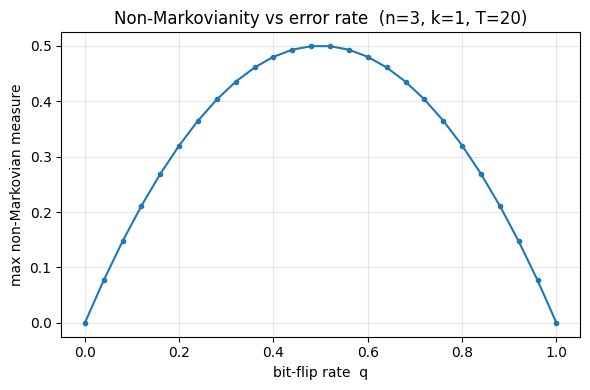

In [23]:
# ---- Sweep the bit-flip rate q and plot the maximised measure ----
T  = 20
qs = np.linspace(0.0, 1.0, 26)
vals = [max_measure(T, q)[0] for q in qs]

plt.figure(figsize=(6, 4))
plt.plot(qs, vals, marker='o', ms=3)
plt.xlabel('bit-flip rate  q')
plt.ylabel('max non-Markovian measure')
plt.title(f'Non-Markovianity vs error rate  (n={n}, k={k}, T={T})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

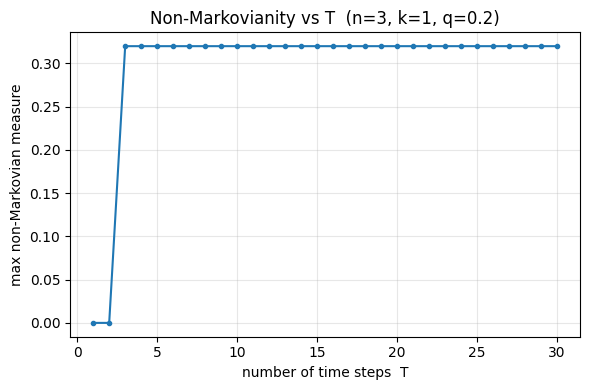

In [22]:
# ---- Measure vs number of time steps T (at fixed q) ----
q    = 0.2
Tmax = 30
channel = make_channel(build_all_channels(Tmax, q))   # build once, reuse for every T

def max_measure_fixed(channel, T):
    """Max non-Markovian measure over basis-state pairs, reusing a prebuilt channel."""
    best = -1.0
    for i in range(dim):
        for j in range(i + 1, dim):
            best = max(best, non_markovian_measure(channel, T, basis_state(i), basis_state(j)))
    return best

Ts   = list(range(1, Tmax + 1))
vals = [max_measure_fixed(channel, T) for T in Ts]

plt.figure(figsize=(6, 4))
plt.plot(Ts, vals, marker='o', ms=3)
plt.xlabel('number of time steps  T')
plt.ylabel('max non-Markovian measure')
plt.title(f'Non-Markovianity vs T  (n={n}, k={k}, q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

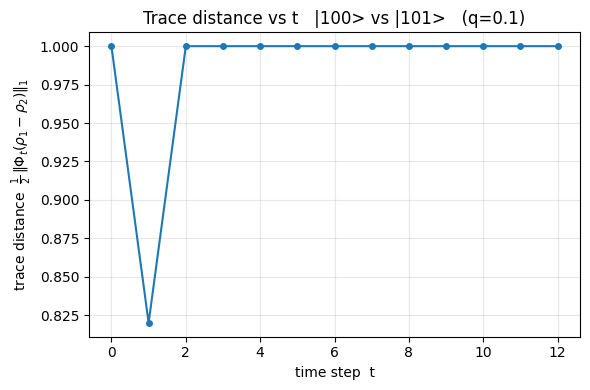

t= 0  D=1.000000
t= 1  D=0.820000
t= 2  D=1.000000
t= 3  D=1.000000
t= 4  D=1.000000
t= 5  D=1.000000
t= 6  D=1.000000
t= 7  D=1.000000
t= 8  D=1.000000
t= 9  D=1.000000
t=10  D=1.000000
t=11  D=1.000000
t=12  D=1.000000


In [20]:
# ---- Raw trace distance vs t for the optimal state pair ----
# This is the un-thresholded quantity behind the BLP measure: D(t) = 1/2 ||Phi_t(rho1-rho2)||_1.
# Markovian (CP-divisible) dynamics => D(t) monotonically non-increasing.
# Any revival (upward step) is exactly what non_markovian_measure sums.
q    = 0.1
Tmax = 12
channel = make_channel(build_all_channels(Tmax, q))

_, (i, j) = max_measure(Tmax, q)                 # optimal basis-state pair at this q
delta = basis_state(i) - basis_state(j)

ts   = list(range(0, Tmax + 1))
dist = [0.5 * trace_norm(channel(t, delta)) for t in ts]

plt.figure(figsize=(6, 4))
plt.plot(ts, dist, marker='o', ms=4)
plt.xlabel('time step  t')
plt.ylabel(r'trace distance  $\frac{1}{2}\,\|\Phi_t(\rho_1-\rho_2)\|_1$')
plt.title(f'Trace distance vs t   |{i:0{n}b}> vs |{j:0{n}b}>   (q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for t, d in zip(ts, dist):
    print(f"t={t:2d}  D={d:.6f}")